In [1]:
# TensorFlow and core libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Keras model and layer components
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, InputLayer, Dense, Flatten, Dropout, BatchNormalization,
    Conv2D, Conv2DTranspose, MaxPool2D, LeakyReLU, Reshape, Add
)

# Optimizers
from tensorflow.keras.optimizers import Adam


2025-08-02 11:17:10.400834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754133430.788320      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754133430.893954      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# 📌 Model and Training Hyperparameters
BATCH_SIZE    = 128             # Number of samples per training batch
IM_SHAPE      = (64, 64, 3)     # Shape of the input image (Height, Width, Channels)
LEARNING_RATE = 2e-4            # Learning rate for the optimizer
LATENT_DIM    = 100             # Dimensionality of the noise vector (used in GANs)
EPOCHS        = 20              # Number of training epochs


In [3]:
# 📥 Loading the CelebA Dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba",
    label_mode=None,  # No labels since this is for GAN training
    image_size=(IM_SHAPE[0], IM_SHAPE[1]),  # Resize images to (64, 64)
    batch_size=BATCH_SIZE                   # Load in batches of 128
)


Found 202599 files.


I0000 00:00:1754133991.638992      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754133991.639823      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# 🔍 Display the loaded dataset object
dataset


<_PrefetchDataset element_spec=TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None)>

In [5]:
def preprocess(image):
    return tf.cast(image, tf.float32) / 127.5 - 1.0


In [6]:
# ✅ Prepare the training dataset pipeline
train_dataset = (
    dataset
    .map(preprocess)  # Apply normalization to [-1, 1]
    .unbatch()        # Flatten batched dataset to individual images
    .shuffle(buffer_size=1024, reshuffle_each_iteration=True)  # Shuffle for randomness
    .batch(BATCH_SIZE, drop_remainder=True)  # Re-batch the shuffled dataset
    .prefetch(tf.data.AUTOTUNE)  # Improve performance by prefetching
)


In [7]:
# 🔍 Check the shape of one batch from the training dataset
for d in train_dataset.take(1):
    print(d.shape)


(128, 64, 64, 3)


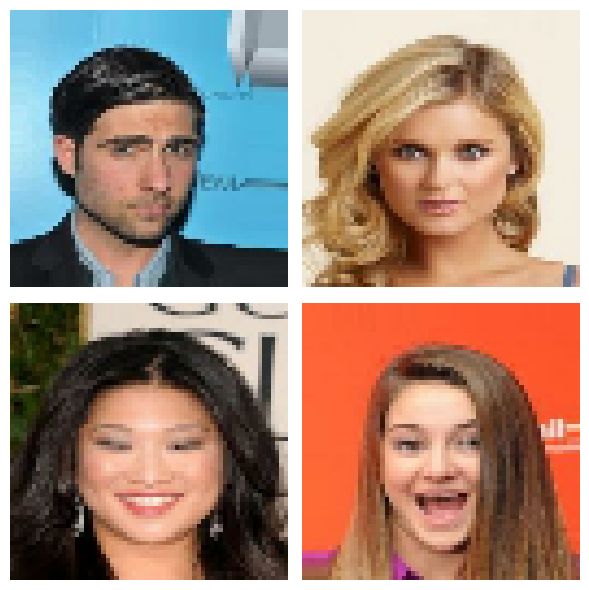

In [8]:
# 🖼️ Visualize a few sample images from the training batch
plt.figure(figsize=(6, 6))
n = 4  # Number of images to display

for i in range(n):
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow((d[i] + 1) / 2)  # Rescale from [-1, 1] back to [0, 1] for display
    plt.axis("off")
plt.tight_layout()
plt.show()


In [9]:
# 🧠 Define the Generator Model
generator = tf.keras.Sequential([
    Input(shape=(LATENT_DIM,)),                        # Input: Random noise vector
    Dense(4 * 4 * LATENT_DIM),                         # Fully connected layer
    Reshape((4, 4, LATENT_DIM)),                       # Reshape to 4x4 feature map

    Conv2DTranspose(512, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2DTranspose(256, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2DTranspose(3, kernel_size=4, strides=2, padding='same', activation='tanh'),  # Output image
], name='generator')


In [10]:
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1600)           │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │       819,712 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,612,867 (13.78 MB)

 Trainable params: 3,611,075 (13.78 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [11]:
# 🧠 Define the Discriminator Model
discriminator = tf.keras.Sequential([
    Input(shape=(IM_SHAPE[0], IM_SHAPE[1], 3)),  # Input image: 64x64x3

    Conv2D(64, kernel_size=4, strides=2, padding='same'),
    LeakyReLU(0.2),

    Conv2D(128, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2D(256, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2D(1, kernel_size=4, strides=2, padding='same'),  # Final conv layer

    Flatten(),
    Dense(1, activation='sigmoid')  # Output: real (1) or fake (0)
], name='discriminator')


In [12]:
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 1)        │         4,097 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,530 (2.53 MB)

 Trainable params: 663,762 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

In [13]:
# 🎨 Custom Callback to Display and Save Generated Images at Epochs 1, 11, 21, ...
class ShowImage(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim=100):
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # Show images if (epoch + 1) % 10 == 1 → Epochs 1, 11, 21, ...
        if (epoch + 1) % 10 == 1:
            n = 6  # Grid size (6x6 = 36 images)
            k = 0
            noise = tf.random.normal(shape=(n * n, self.latent_dim))  # Sample random noise
            generated_images = self.model.generator(noise)

            # Rescale the images to [0, 1] from [-1, 1]
            generated_images = (generated_images + 1) / 2

            # Plotting the images in a 6x6 grid
            plt.figure(figsize=(16, 16))
            for i in range(n):
                for j in range(n):
                    ax = plt.subplot(n, n, k + 1)
                    plt.imshow(generated_images[k])
                    plt.axis('off')  # Hide axes
                    k += 1

            plt.tight_layout()
            plt.show()  # Display the generated image grid


In [14]:
# 🔁 Custom GAN Training Class
class GAN(tf.keras.Model):
    def __init__(self, discriminator, generator):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name='d_loss')
        self.g_loss_metric = tf.keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        ### Discriminator Training ###
        random_noise = tf.random.normal(shape=(batch_size, LATENT_DIM))
        fake_images = self.generator(random_noise)

        # Label smoothing + noise
        real_labels = tf.ones((batch_size, 1)) + 0.25 * tf.random.uniform((batch_size, 1), -1, 1)
        fake_labels = tf.zeros((batch_size, 1)) + 0.25 * tf.random.uniform((batch_size, 1), 0, 1)

        with tf.GradientTape() as tape:
            real_predictions = self.discriminator(real_images)
            d_loss_real = self.loss_fn(real_labels, real_predictions)

            fake_predictions = self.discriminator(fake_images)
            d_loss_fake = self.loss_fn(fake_labels, fake_predictions)

            d_loss = d_loss_real + d_loss_fake

        d_grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        ### Generator Training ###
        random_noise = tf.random.normal(shape=(batch_size, LATENT_DIM))
        misleading_labels = tf.ones((batch_size, 1))  # Flip labels for generator training

        with tf.GradientTape() as tape:
            fake_predictions = self.discriminator(self.generator(random_noise))
            g_loss = self.loss_fn(misleading_labels, fake_predictions)

        g_grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update tracked metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            'd_loss': self.d_loss_metric.result(),
            'g_loss': self.g_loss_metric.result()
        }


In [15]:
# ⚙️ Instantiate and Compile the GAN Model
gan = GAN(discriminator, generator)

gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=0.5
    ),
    g_optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=0.5
    ),
    loss_fn=tf.keras.losses.BinaryCrossentropy()
)


In [16]:
!mkdir generated

Epoch 1/21


I0000 00:00:1754134007.442744      69 service.cc:148] XLA service 0x78eb50002b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754134007.444033      69 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1754134007.444054      69 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1754134008.570619      69 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1754134020.766672      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   1582/Unknown 424s 254ms/step - d_loss: 1.0753 - g_loss: 1.0661

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


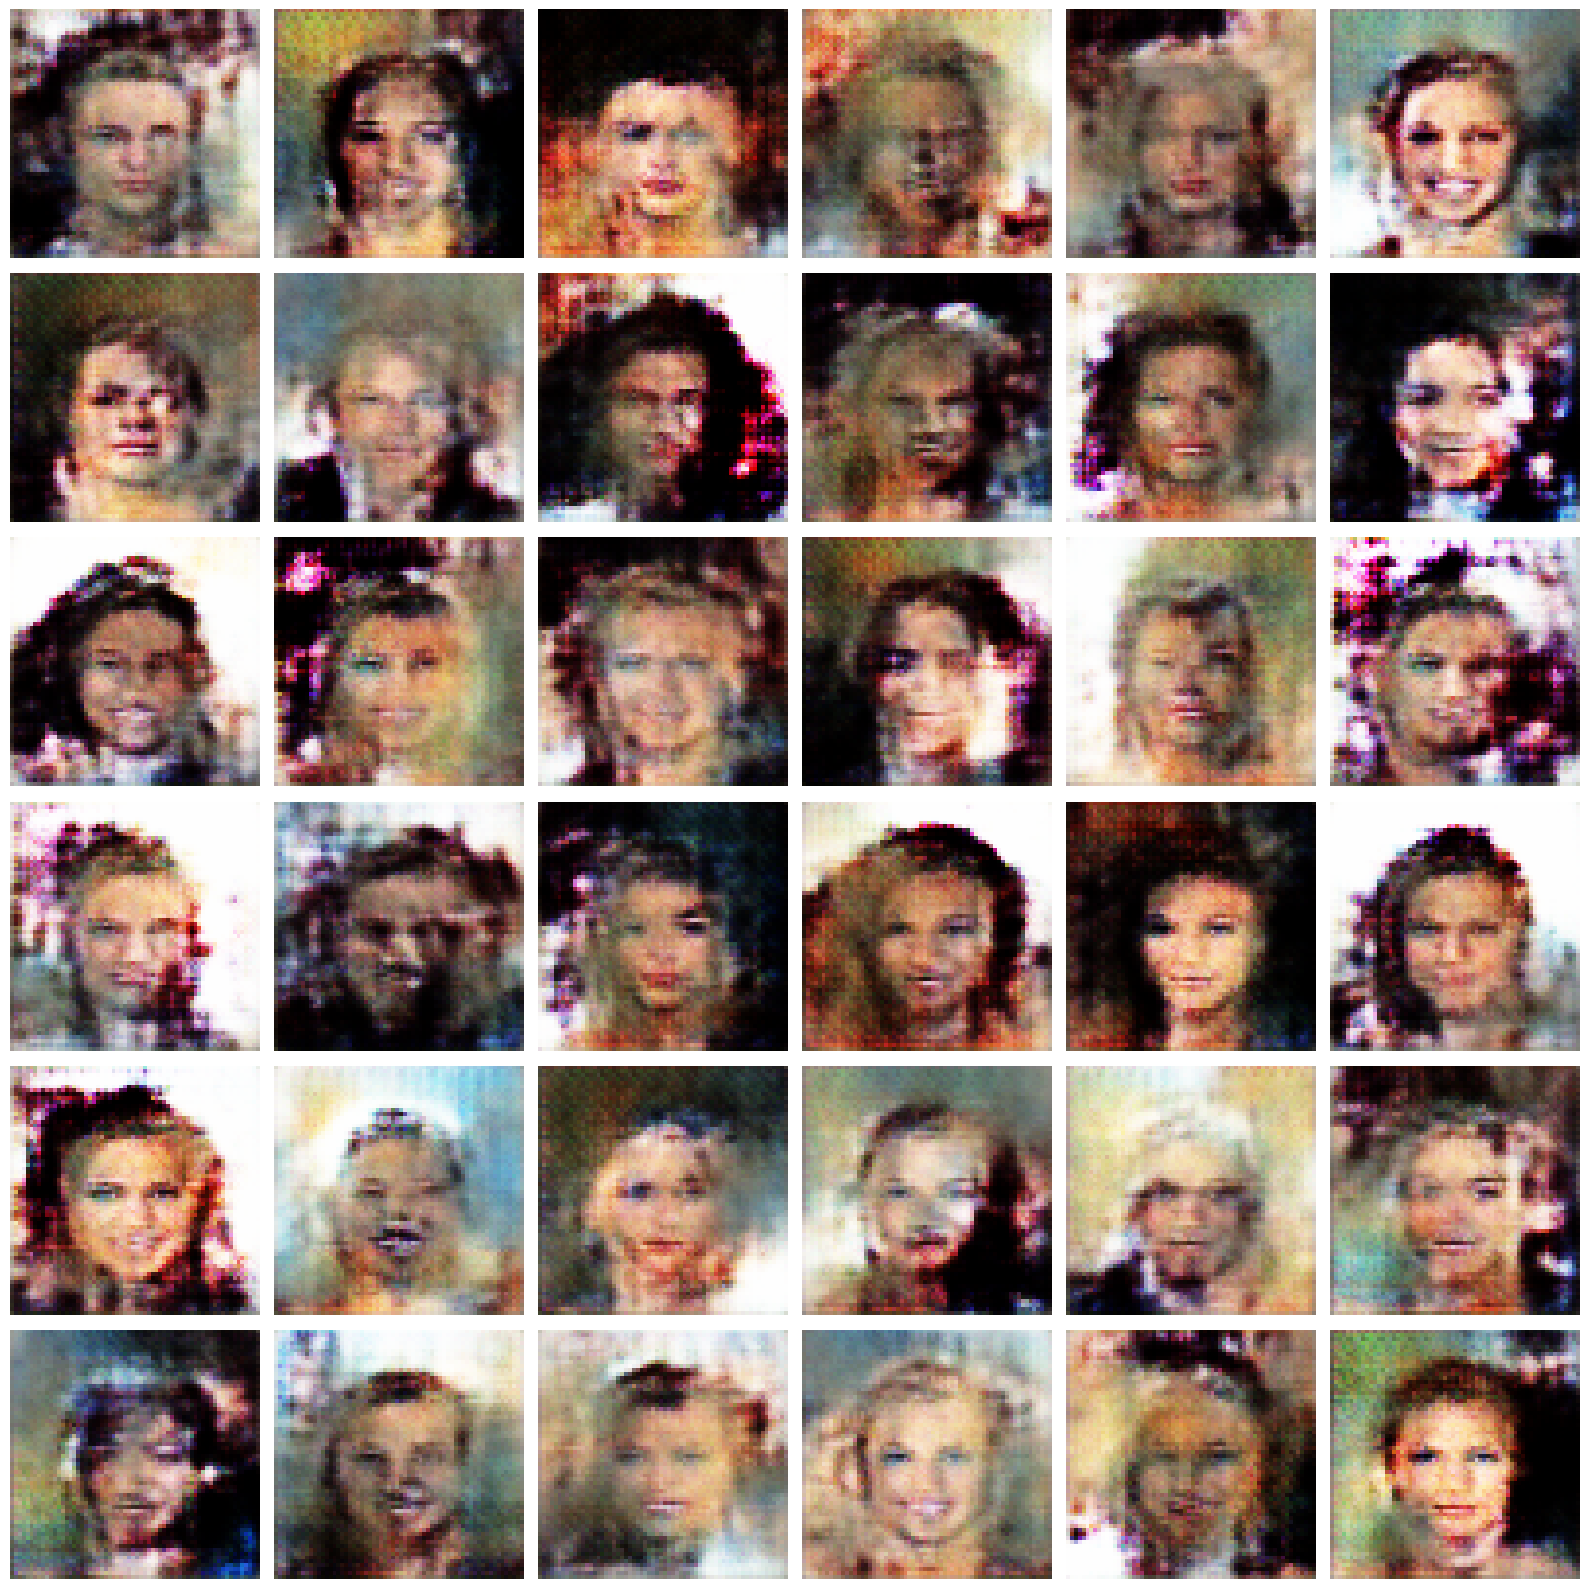

1582/1582 ━━━━━━━━━━━━━━━━━━━━ 425s 255ms/step - d_loss: 1.0753 - g_loss: 1.0661
Epoch 2/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.1467 - g_loss: 0.9615
Epoch 3/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.1883 - g_loss: 0.9018
Epoch 4/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2088 - g_loss: 0.8673
Epoch 5/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.2139 - g_loss: 0.8499
Epoch 6/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2179 - g_loss: 0.8385
Epoch 7/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2330 - g_loss: 0.8250
Epoch 8/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2167 - g_loss: 0.8263
Epoch 9/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2076 - g_loss: 0.8170
Epoch 10/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.2031 - g_loss: 0.8316
Epoch 11/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - d_loss: 1.2103 - g_loss: 0.8493

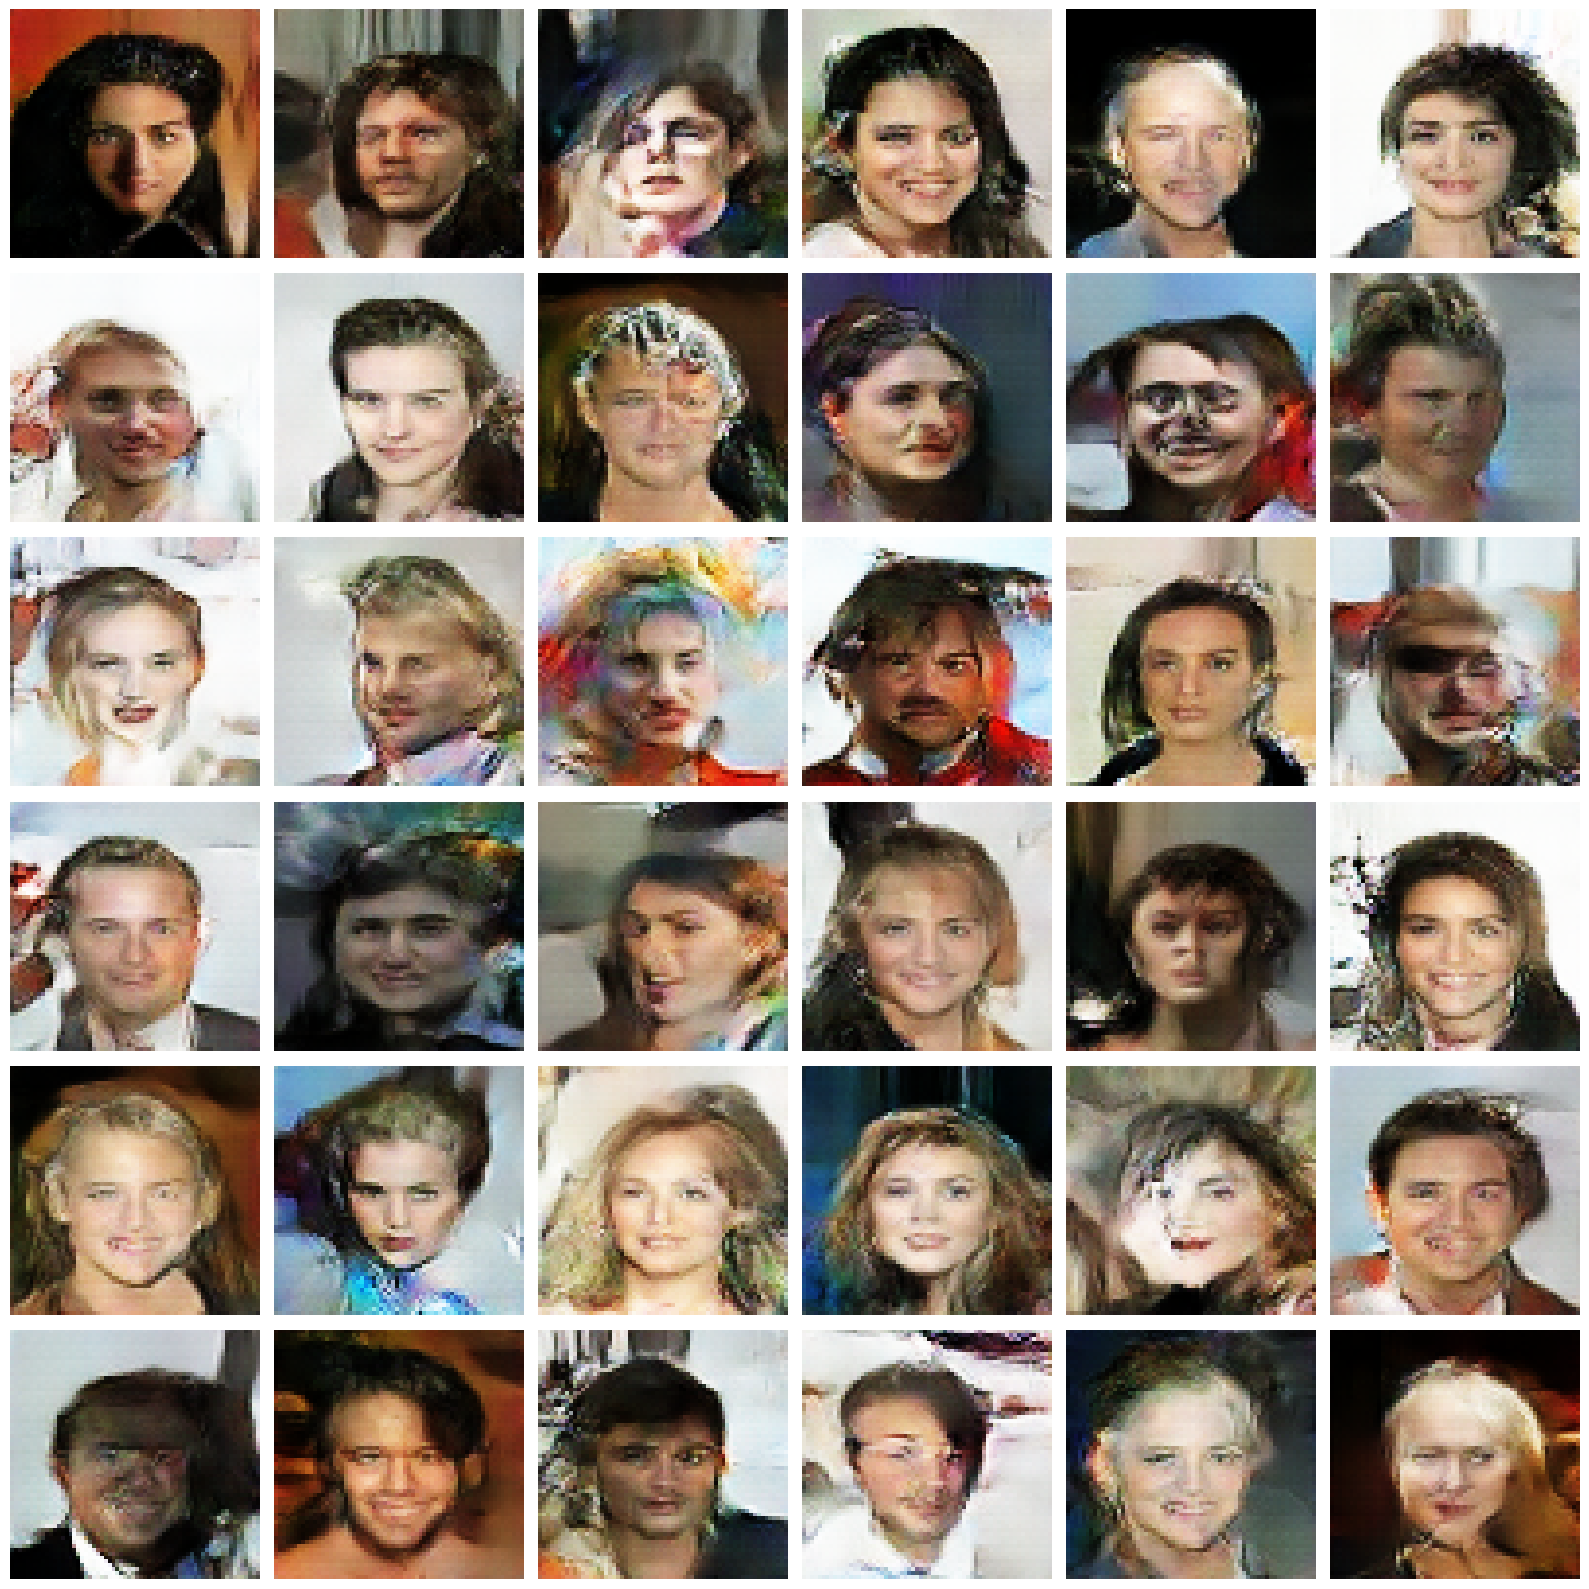

1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 191ms/step - d_loss: 1.2103 - g_loss: 0.8493
Epoch 12/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.2024 - g_loss: 0.8436
Epoch 13/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.2073 - g_loss: 0.8500
Epoch 14/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.2111 - g_loss: 0.8546
Epoch 15/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 323s 190ms/step - d_loss: 1.1756 - g_loss: 0.8813
Epoch 16/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.1638 - g_loss: 0.8875
Epoch 17/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 301s 190ms/step - d_loss: 1.1710 - g_loss: 0.8979
Epoch 18/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.1441 - g_loss: 0.9140
Epoch 19/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.1614 - g_loss: 0.9123
Epoch 20/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 302s 190ms/step - d_loss: 1.1478 - g_loss: 0.9336
Epoch 21/21
1582/1582 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - d_loss: 1.1677 - g_loss

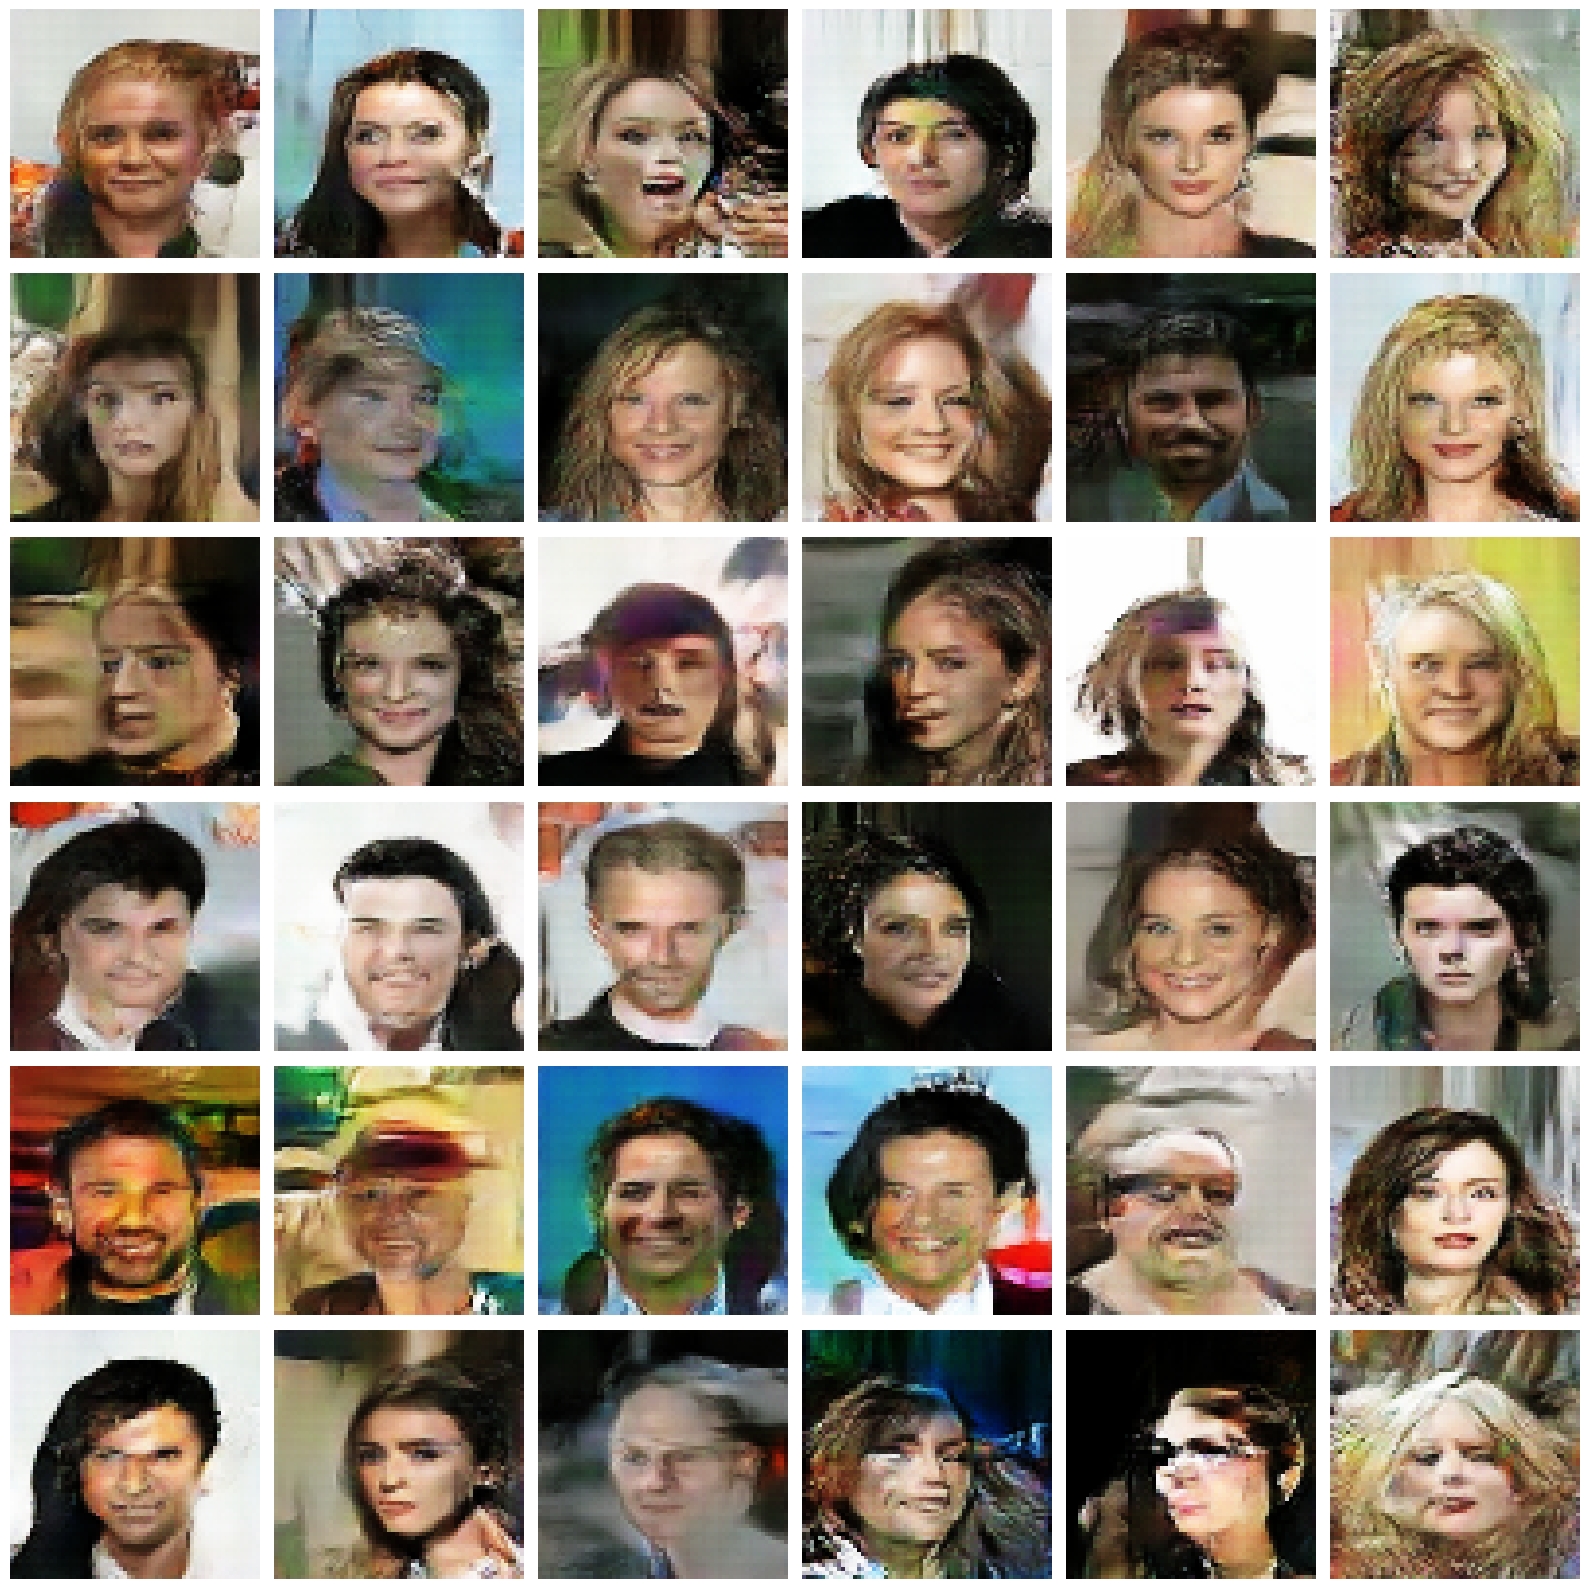

1582/1582 ━━━━━━━━━━━━━━━━━━━━ 303s 191ms/step - d_loss: 1.1677 - g_loss: 0.9319


In [17]:
# 🚀 Start GAN Training
EPOCHS = 21

history = gan.fit(
    train_dataset,
    epochs=EPOCHS,
    callbacks=[ShowImage(LATENT_DIM)]  # Save and show generated samples after 10 epochs
)


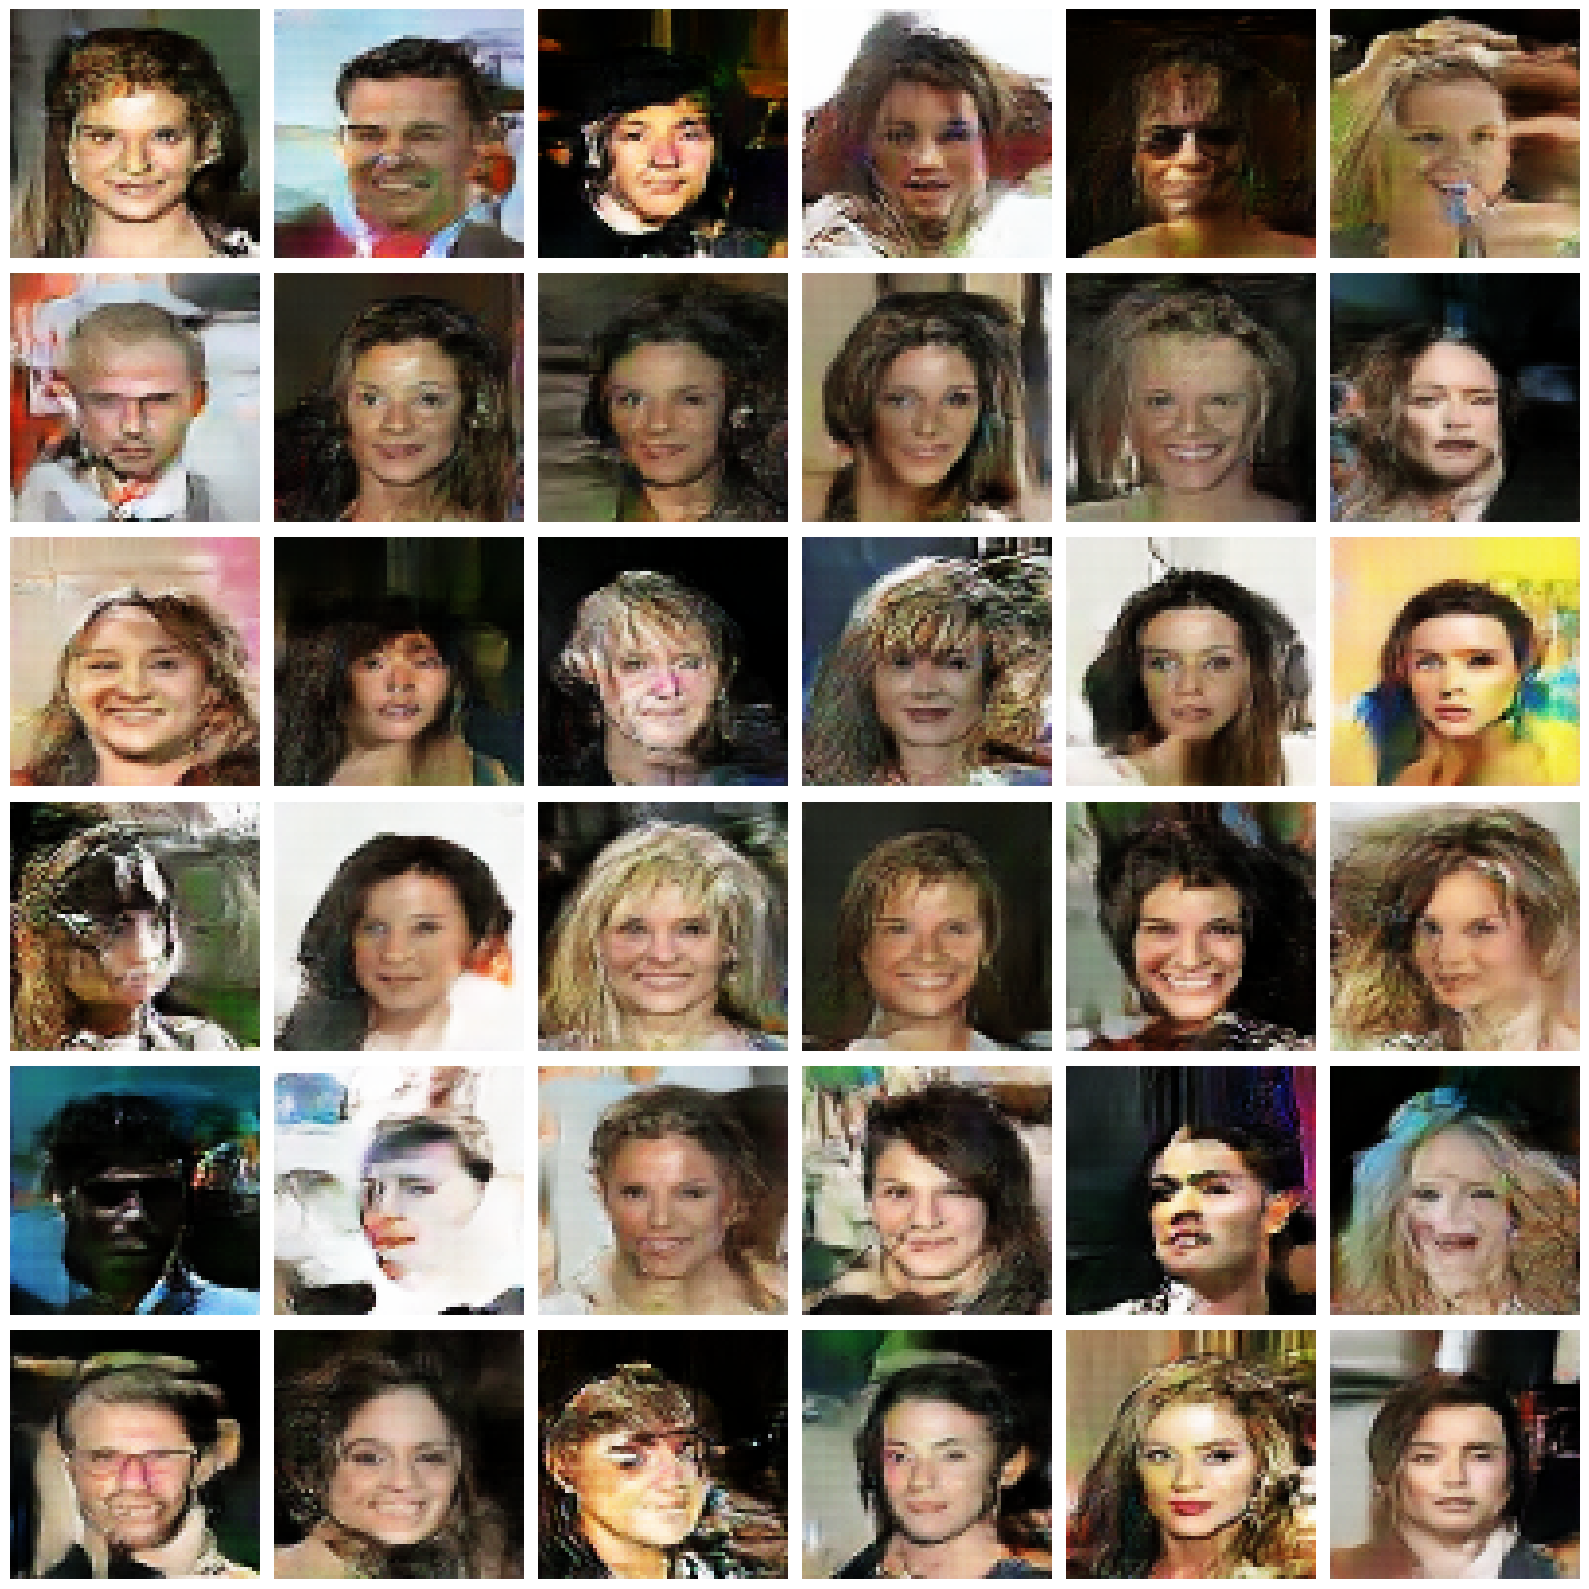

In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the number of images you want to generate (e.g., 6x6 grid)
n = 6  # Grid size (6x6 = 36 images)

# Generate random noise (latent vector)
latent_dim = 100  # The latent dimension used during training
noise = tf.random.normal(shape=(n * n, latent_dim))  # n*n random noise vectors

# Generate images using the trained generator model
generated_images = generator(noise)

# Rescale the images to the range [0, 1]
generated_images = (generated_images + 1) / 2  # Since output of generator is in range [-1, 1]

# Plotting the images in a grid (6x6)
plt.figure(figsize=(16, 16))
k = 0
for i in range(n):
    for j in range(n):
        ax = plt.subplot(n, n, k + 1)
        plt.imshow(generated_images[k])
        plt.axis('off')  # Hide axis labels
        k += 1

plt.tight_layout()
plt.show()  # Display the images


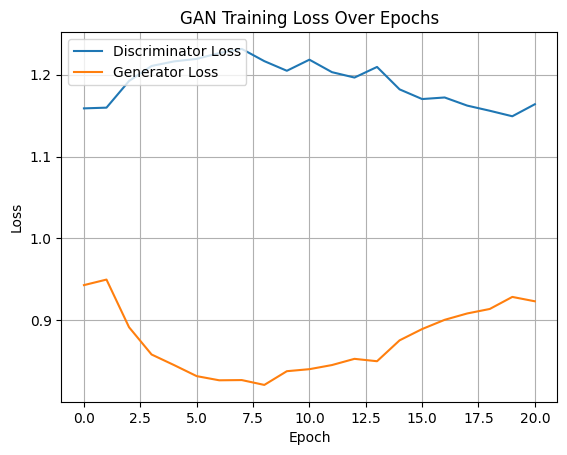

In [19]:
# 📉 Plot Discriminator and Generator Losses
plt.plot(history.history['d_loss'], label='Discriminator Loss')
plt.plot(history.history['g_loss'], label='Generator Loss')
plt.title('GAN Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [20]:
# Save the entire combined GAN model (generator + discriminator)
gan.save('gan_model.h5')
